In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import timm
import numpy as np
import matplotlib.pyplot as plt

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize

In [2]:
train_path = "/kaggle/input/datasets/obulisainaren/retinal-oct-c8/RetinalOCT_Dataset/RetinalOCT_Dataset/train"
val_path   = "/kaggle/input/datasets/obulisainaren/retinal-oct-c8/RetinalOCT_Dataset/RetinalOCT_Dataset/val"
test_path  = "/kaggle/input/datasets/obulisainaren/retinal-oct-c8/RetinalOCT_Dataset/RetinalOCT_Dataset/test"

In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

num_classes = 8
n_qubits = 4
batch_size = 16
epochs = 50
lr = 1e-4

checkpoint_path = "/kaggle/working/checkpoint.pth"
final_model_path = "final_model.pth"


In [4]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

train_dataset = datasets.ImageFolder(train_path, transform=transform)
val_dataset   = datasets.ImageFolder(val_path, transform=transform)
test_dataset  = datasets.ImageFolder(test_path, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

class_names = train_dataset.classes
print("Classes:", class_names)

Classes: ['AMD', 'CNV', 'CSR', 'DME', 'DR', 'DRUSEN', 'MH', 'NORMAL']


In [5]:
class QuantumLayer(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return torch.sin(x)

In [6]:
class QuantumSwinTransformer(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.swin = timm.create_model(
            'swin_tiny_patch4_window7_224',
            pretrained=False,
            num_classes=0
        )

        self.fc1 = nn.Linear(self.swin.num_features, n_qubits)
        self.quantum = QuantumLayer()

        self.fc_final = nn.Linear(self.swin.num_features + n_qubits, num_classes)

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                
                if m.bias is not None:   # ✅ IMPORTANT FIX
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        features = self.swin(x)

        q = torch.tanh(self.fc1(features))
        q_out = self.quantum(q)

        combined = torch.cat((features, q_out), dim=1)

        return self.fc_final(combined)

In [7]:
model = QuantumSwinTransformer(num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=lr)

In [19]:
import os
import torch

# Paths
save_checkpoint_path = "/kaggle/working/checkpoint.pth"
final_model_path = "/kaggle/working/final_model.pth"

start_epoch = 0
best_acc = 0

# Initialize lists
train_losses = []
val_losses = []

if os.path.exists(checkpoint_path):
    print("🔄 Loading checkpoint...")

    checkpoint = torch.load(checkpoint_path, map_location=device)

    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

    start_epoch = checkpoint['epoch'] + 1
    best_acc = checkpoint['best_acc']

    # ✅ Load previous losses
    train_losses = checkpoint.get('train_losses', [])
    val_losses = checkpoint.get('val_losses', [])

    print(f"✅ Resuming from epoch {start_epoch}")
else:
    print("🚀 Training from scratch")

🔄 Loading checkpoint...
✅ Resuming from epoch 26


In [20]:
patience = 10  
counter = 0
best_val_loss = float('inf')

for epoch in range(start_epoch, epochs):

    model.train()
    running_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)

    # ===== VALIDATION =====
    model.eval()
    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_loss /= len(val_loader)
    val_losses.append(val_loss)

    acc = correct / total

    print(f"Epoch [{epoch+1}/{epochs}] "
          f"Train Loss: {train_loss:.4f} "
          f"Val Loss: {val_loss:.4f} "
          f"Acc: {acc:.4f}")

    # ===== SAVE CHECKPOINT (WITH LOSSES) =====
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'best_acc': best_acc,
        'train_losses': train_losses,   # ✅ IMPORTANT
        'val_losses': val_losses        # ✅ IMPORTANT
    }, save_checkpoint_path)

    print("💾 Checkpoint saved")

    # ===== SAVE BEST MODEL =====
    if acc > best_acc:
        best_acc = acc
        torch.save(model.state_dict(), final_model_path)
        print("🏆 Best model updated")

    # ===== EARLY STOPPING =====
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
    else:
        counter += 1

    print(f"EarlyStopping Counter: {counter}/{patience}")

    if counter >= patience:
        print("⛔ Early stopping triggered!")
        break

Epoch [27/50] Train Loss: 0.1070 Val Loss: 0.3597 Acc: 0.8982
💾 Checkpoint saved
EarlyStopping Counter: 0/10
Epoch [28/50] Train Loss: 0.1021 Val Loss: 0.3597 Acc: 0.8982
💾 Checkpoint saved
EarlyStopping Counter: 1/10
Epoch [29/50] Train Loss: 0.1040 Val Loss: 0.3597 Acc: 0.8982
💾 Checkpoint saved
EarlyStopping Counter: 2/10
Epoch [30/50] Train Loss: 0.1022 Val Loss: 0.3597 Acc: 0.8982
💾 Checkpoint saved
EarlyStopping Counter: 3/10
Epoch [31/50] Train Loss: 0.1042 Val Loss: 0.3597 Acc: 0.8982
💾 Checkpoint saved
EarlyStopping Counter: 4/10
Epoch [32/50] Train Loss: 0.1032 Val Loss: 0.3597 Acc: 0.8982
💾 Checkpoint saved
EarlyStopping Counter: 5/10
Epoch [33/50] Train Loss: 0.1017 Val Loss: 0.3597 Acc: 0.8982
💾 Checkpoint saved
EarlyStopping Counter: 6/10
Epoch [34/50] Train Loss: 0.1001 Val Loss: 0.3597 Acc: 0.8982
💾 Checkpoint saved
EarlyStopping Counter: 7/10
Epoch [35/50] Train Loss: 0.1015 Val Loss: 0.3597 Acc: 0.8982
💾 Checkpoint saved
EarlyStopping Counter: 8/10
Epoch [36/50] Train

In [21]:
model.load_state_dict(torch.load(final_model_path, map_location=device))
model.eval()

all_labels = []
all_preds = []
all_probs = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

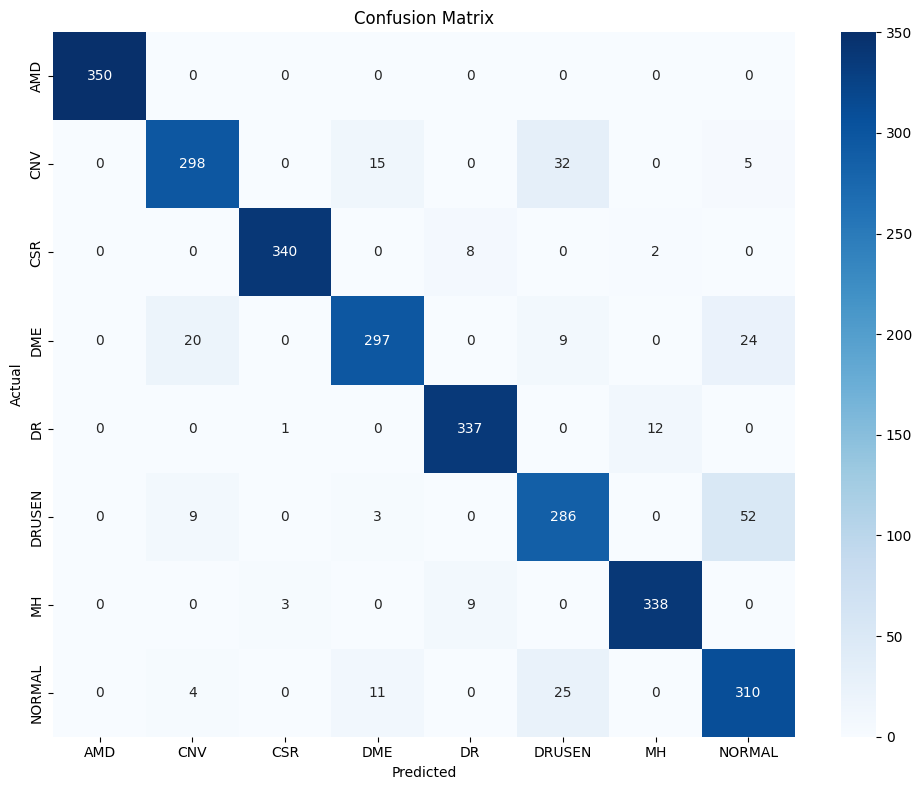

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Class names (important)
class_names = ['AMD','CNV','CSR','DME','DR','DRUSEN','MH','NORMAL']

# Plot
plt.figure(figsize=(10,8))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

In [23]:
print(classification_report(all_labels, all_preds, target_names=class_names))

              precision    recall  f1-score   support

         AMD       1.00      1.00      1.00       350
         CNV       0.90      0.85      0.88       350
         CSR       0.99      0.97      0.98       350
         DME       0.91      0.85      0.88       350
          DR       0.95      0.96      0.96       350
      DRUSEN       0.81      0.82      0.81       350
          MH       0.96      0.97      0.96       350
      NORMAL       0.79      0.89      0.84       350

    accuracy                           0.91      2800
   macro avg       0.91      0.91      0.91      2800
weighted avg       0.91      0.91      0.91      2800



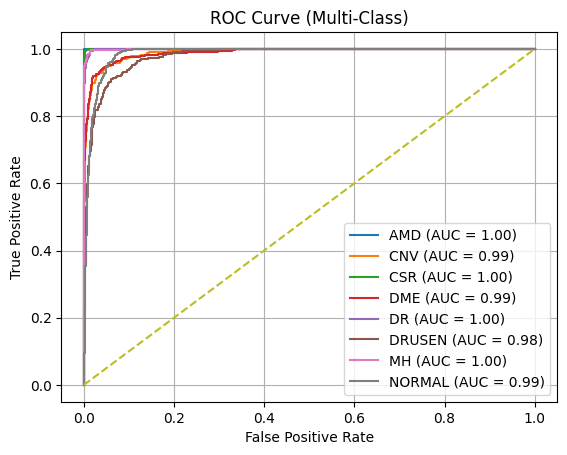

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Number of classes
num_classes = 8

# Class names
class_names = ['AMD','CNV','CSR','DME','DR','DRUSEN','MH','NORMAL']

# Convert labels to one-hot
y_true = label_binarize(all_labels, classes=list(range(num_classes)))

# Convert probabilities to numpy
y_score = np.array(all_probs)

# Plot ROC curves
plt.figure()

for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_true[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{class_names[i]} (AUC = {roc_auc:.2f})")

# Diagonal line
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Multi-Class)")
plt.legend(loc="lower right")

plt.grid()
plt.show()

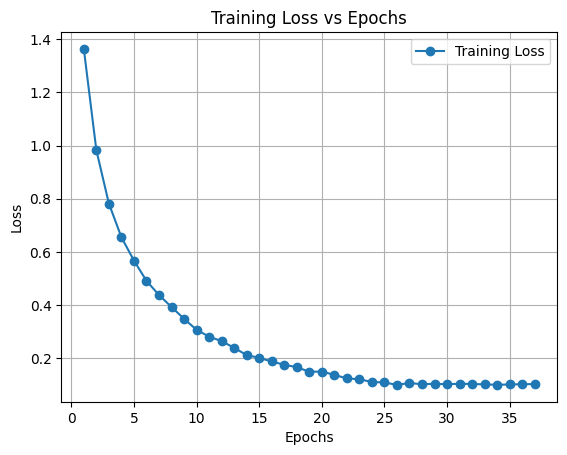

In [25]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(train_losses) + 1)

plt.figure()
plt.plot(epochs_range, train_losses, marker='o', label="Training Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss vs Epochs")

plt.legend()
plt.grid()

plt.show()

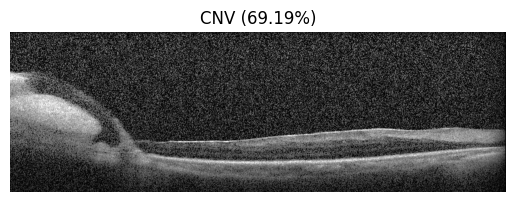

Prediction: CNV
Confidence: 69.19%


In [26]:
import torch
from PIL import Image
import matplotlib.pyplot as plt
from torchvision import transforms

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Class names (same order as training)
class_names = ['AMD','CNV','CSR','DME','DR','DRUSEN','MH','NORMAL']

# Load model
model = QuantumSwinTransformer(num_classes=8).to(device)
model.load_state_dict(torch.load("/kaggle/working/final_model.pth", map_location=device))
model.eval()

# Image transform (same as training)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

# Load image
img_path = "/kaggle/input/datasets/obulisainaren/retinal-oct-c8/RetinalOCT_Dataset/RetinalOCT_Dataset/test/CNV/cnv_test_1005.jpg"  # 🔴 change this
image = Image.open(img_path).convert("RGB")

# Preprocess
input_tensor = transform(image).unsqueeze(0).to(device)

# Prediction
with torch.no_grad():
    outputs = model(input_tensor)
    probs = torch.softmax(outputs, dim=1)
    confidence, pred = torch.max(probs, 1)

# Result
predicted_class = class_names[pred.item()]
confidence_score = confidence.item() * 100

# Display
plt.imshow(image)
plt.title(f"{predicted_class} ({confidence_score:.2f}%)")
plt.axis('off')
plt.show()

# Print
print("Prediction:", predicted_class)
print("Confidence:", f"{confidence_score:.2f}%")